# 👥 Day 27 - Customer Segmentation with RFM + K-Means
### Unsupervised segmentation of customers based on recency, frequency, and monetary patterns using K-Means and RFM analytics

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib  # pip install joblib
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = "data.csv"
OUTPUT_RFM_CSV = "rfm_kmeans_customers.csv"
SAVED_SCALER = "rfm_scaler.joblib"
SAVED_MODEL = "kmeans_rfm_model.joblib"
RANDOM_STATE = 42

# Default choice of clusters (you can change after inspecting the plots)
DEFAULT_K = 4

In [2]:
print("Loading data...")
df = pd.read_csv(DATA_PATH, encoding="ISO-8859-1")

Loading data...


In [3]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df = df.dropna(subset=['CustomerID'])
if 'InvoiceNo' in df.columns:
    df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
if 'Quantity' in df.columns:
    df = df[df['Quantity'] > 0]
if 'UnitPrice' in df.columns:
    df = df[df['UnitPrice'] > 0]

df['Amount'] = df.get('Amount', df['Quantity'] * df['UnitPrice'])
df = df[['CustomerID', 'InvoiceDate', 'InvoiceNo', 'Quantity', 'UnitPrice', 'Amount']]
df['CustomerID'] = df['CustomerID'].astype(str)

In [4]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date.date())

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': lambda x: x.nunique(),
    'Amount': 'sum'
}).rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'Amount': 'Monetary'}).reset_index()

# Quick checks
print("RFM rows:", rfm.shape[0])
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

Snapshot date: 2011-12-10
RFM rows: 4338
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2054.27
std     100.01       7.70    8989.23
min       1.00       1.00       3.75
25%      18.00       1.00     307.41
50%      51.00       2.00     674.48
75%     142.00       5.00    1661.74
max     374.00     209.00  280206.02


In [5]:
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])

# Keep features for clustering
features = rfm[['Recency', 'Frequency_log', 'Monetary_log']].copy()

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Save scaler for future predictions
joblib.dump(scaler, SAVED_SCALER)
print("Saved scaler to", SAVED_SCALER)

Saved scaler to rfm_scaler.joblib


Computing inertia & silhouette for k=2..8 (this may take a moment)...
k=2: inertia=6872.8, silhouette=0.4064
k=3: inertia=4298.6, silhouette=0.4156
k=4: inertia=3242.1, silhouette=0.3805
k=5: inertia=2760.9, silhouette=0.3433
k=6: inertia=2397.2, silhouette=0.3307
k=7: inertia=2166.7, silhouette=0.2998
k=8: inertia=1960.5, silhouette=0.3005


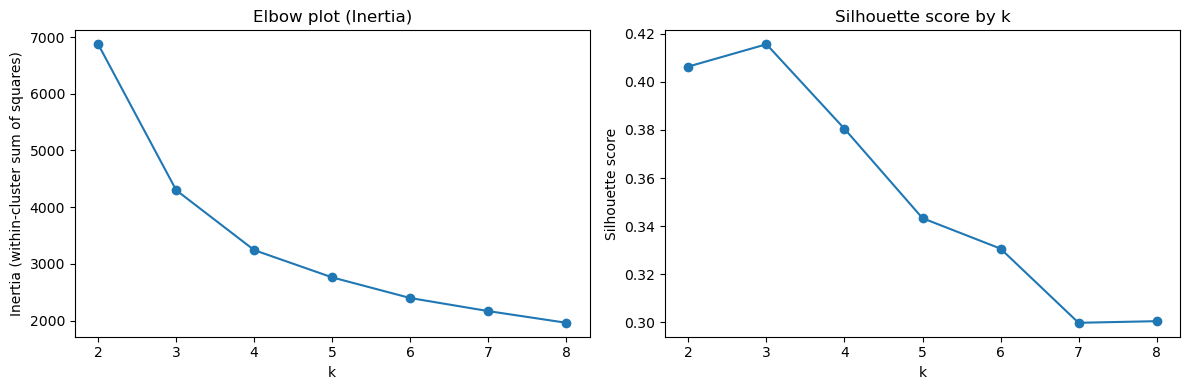


Pick a good k where inertia 'elbows' and silhouette is high. Defaulting to k = 4


In [7]:
print("Computing inertia & silhouette for k=2..8 (this may take a moment)...")
inertias = []
silhouettes = []
ks = range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouettes.append(sil)
    print(f"k={k}: inertia={km.inertia_:.1f}, silhouette={sil:.4f}")

# Plot elbow and silhouette
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(ks, inertias, marker='o')
plt.title("Elbow plot (Inertia)")
plt.xlabel("k")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.subplot(1,2,2)
plt.plot(ks, silhouettes, marker='o')
plt.title("Silhouette score by k")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.tight_layout()
plt.show()

print("\nPick a good k where inertia 'elbows' and silhouette is high. Defaulting to k =", DEFAULT_K)

In [8]:
k = DEFAULT_K
kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
rfm['KMeans_cluster'] = kmeans.fit_predict(X_scaled)

# Save model
joblib.dump(kmeans, SAVED_MODEL)
print("Saved KMeans model to", SAVED_MODEL)

Saved KMeans model to kmeans_rfm_model.joblib


In [9]:
print("Silhouette (final):", silhouette_score(X_scaled, rfm['KMeans_cluster']).round(4))
profile = rfm.groupby('KMeans_cluster').agg({
    'CustomerID': 'nunique',
    'Recency': 'median',
    'Frequency': 'median',
    'Monetary': 'median'
}).rename(columns={'CustomerID': 'NumCustomers'}).sort_values('NumCustomers', ascending=False)

print("\nCluster profile (medians):\n", profile)

Silhouette (final): 0.3805

Cluster profile (medians):
                 NumCustomers  Recency  Frequency  Monetary
KMeans_cluster                                            
0                       1447     30.0        4.0   1339.41
1                       1392     51.0        1.0    348.35
2                        941    255.0        1.0    298.11
3                        558     10.0       12.0   4628.52


In [10]:
def rank_score(df_segment):
    # recency_rank: smaller recency => higher rank; invert rank
    recency_rank = (-df_segment['Recency'].rank()).rank()  # not used directly, we use medians below
    return None  # placeholder, we won't use per-row ranking here

# Compute cluster medians and a simple numeric 'value' to order clusters
cluster_stats = rfm.groupby('KMeans_cluster').agg({
    'Recency': 'median',
    'Frequency': 'median',
    'Monetary': 'median'
}).reset_index()

# Normalize medians to 0..1 (simple min-max) for scoring
def minmax(series):
    return (series - series.min()) / (series.max() - series.min() + 1e-9)

cluster_stats['rec_norm'] = 1 - minmax(cluster_stats['Recency'])        # lower recency -> better -> invert
cluster_stats['freq_norm'] = minmax(cluster_stats['Frequency'])        # higher freq -> better
cluster_stats['mon_norm'] = minmax(cluster_stats['Monetary'])          # higher monetary -> better

# Weighted score (you can tune weights)
cluster_stats['score'] = 0.4 * cluster_stats['rec_norm'] + 0.3 * cluster_stats['freq_norm'] + 0.3 * cluster_stats['mon_norm']

# Map cluster label to rank by score (higher score = better segment)
cluster_stats = cluster_stats.sort_values('score', ascending=False).reset_index(drop=True)
cluster_stats['segment_name'] = ['Champions', 'Loyal', 'At Risk', 'Lost'][:len(cluster_stats)]

print("\nCluster stats and assigned segment names:")
print(cluster_stats[['KMeans_cluster','Recency','Frequency','Monetary','score','segment_name']])

# Build mapping
cluster_to_name = dict(zip(cluster_stats['KMeans_cluster'], cluster_stats['segment_name']))
rfm['Segment'] = rfm['KMeans_cluster'].map(cluster_to_name)


Cluster stats and assigned segment names:
   KMeans_cluster  Recency  Frequency  Monetary         score segment_name
0               3     10.0       12.0   4628.52  1.000000e+00    Champions
1               0     30.0        4.0   1339.41  5.213038e-01        Loyal
2               1     51.0        1.0    348.35  3.365417e-01      At Risk
3               2    255.0        1.0    298.11  1.632650e-12         Lost


In [11]:
rfm.to_csv(OUTPUT_RFM_CSV, index=False)
print(f"Saved RFM + cluster results to {OUTPUT_RFM_CSV}")

# Show sample customers by segment
for seg in rfm['Segment'].unique():
    print("\nSegment:", seg)
    display = rfm[rfm['Segment'] == seg].sort_values('Monetary', ascending=False).head(5)
    print(display[['CustomerID','Recency','Frequency','Monetary']])

Saved RFM + cluster results to rfm_kmeans_customers.csv

Segment: Loyal
     CustomerID  Recency  Frequency  Monetary
0       12346.0      326          1  77183.60
152     12536.0       43          3  12601.83
2678    16000.0        3          3  12393.70
50      12409.0       79          3  11072.67
196     12590.0      211          2   9864.26

Segment: Champions
     CustomerID  Recency  Frequency   Monetary
1689    14646.0        2         73  280206.02
4201    18102.0        1         60  259657.30
3728    17450.0        8         46  194550.79
3008    16446.0        1          2  168472.50
1879    14911.0        1        201  143825.06

Segment: Lost
     CustomerID  Recency  Frequency  Monetary
332     12755.0      281          2   3811.95
2546    15808.0      306          4   3734.97
597     13135.0      197          1   3096.00
227     12625.0      212          2   2683.82
1533    14439.0      320          1   2661.24

Segment: At Risk
     CustomerID  Recency  Frequency  Mone

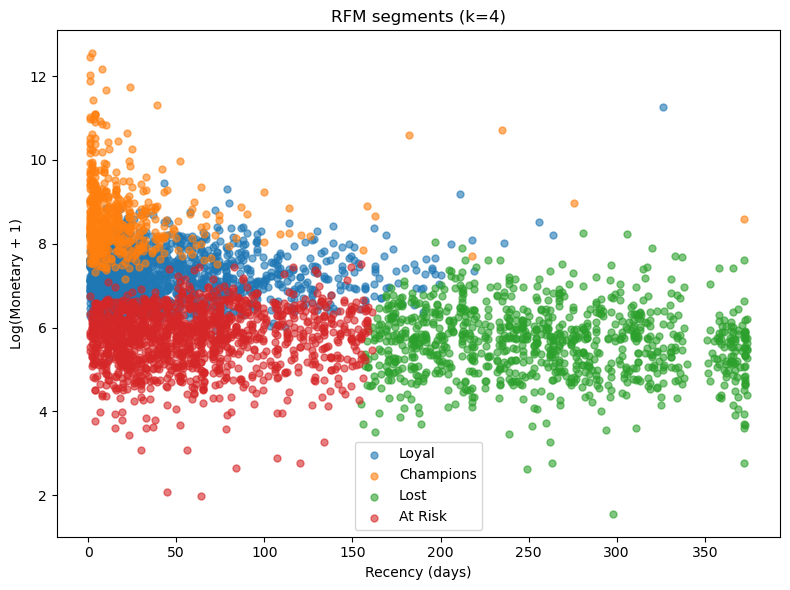

In [12]:
plt.figure(figsize=(8,6))
unique_segs = rfm['Segment'].unique()
colors = plt.cm.tab10.colors
for i, seg in enumerate(unique_segs):
    mask = rfm['Segment'] == seg
    plt.scatter(rfm.loc[mask, 'Recency'], np.log1p(rfm.loc[mask, 'Monetary']),
                label=seg, alpha=0.6, s=25, color=colors[i % len(colors)])
plt.xlabel("Recency (days)")
plt.ylabel("Log(Monetary + 1)")
plt.title(f"RFM segments (k={k})")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
def predict_new_customer(last_purchase_date_str, frequency, monetary):
    """
    last_purchase_date_str: string "YYYY-MM-DD" or datetime
    frequency: integer count of distinct invoices for this customer
    monetary: total amount spent (float)
    Returns: predicted segment name and cluster id
    """
    # compute Recency
    if isinstance(last_purchase_date_str, str):
        last_purchase_date = pd.to_datetime(last_purchase_date_str)
    else:
        last_purchase_date = last_purchase_date_str
    recency_days = (snapshot_date - last_purchase_date).days
    freq_log = np.log1p(frequency)
    mon_log = np.log1p(monetary)
    arr = np.array([[recency_days, freq_log, mon_log]])
    arr_scaled = scaler.transform(arr)
    cl = kmeans.predict(arr_scaled)[0]
    seg = cluster_to_name.get(cl, f"cluster_{cl}")
    return {"cluster": int(cl), "segment": seg, "recency": int(recency_days), "frequency": frequency, "monetary": monetary}

# Example usage of the helper
print("\nExample prediction for a new customer:")
example = predict_new_customer(last_purchase_date_str=str(snapshot_date.date() - pd.Timedelta(days=10)),
                               frequency=3, monetary=120.0)
print(example)


Example prediction for a new customer:
{'cluster': 1, 'segment': 'At Risk', 'recency': 10, 'frequency': 3, 'monetary': 120.0}
